In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [4]:
project_path = Path("/content/drive/MyDrive/ISL_GAN_FewShot_Project")

landmark_dir = project_path / "data" / "landmarks"
augmented_dir = project_path / "data" / "augmented"
model_dir = project_path / "models" / "fewshot"
model_dir.mkdir(parents=True, exist_ok=True)

with open(landmark_dir / "class_mapping.json", "r") as f:
    mapping = json.load(f)

class_to_idx = mapping["class_to_idx"]
idx_to_class = {int(k): v for k, v in mapping["idx_to_class"].items()}
num_classes = len(class_to_idx)

print("Number of classes:", num_classes)

Number of classes: 35


In [5]:
X_augmented = np.load(augmented_dir / "X_augmented.npy")
y_augmented = np.load(augmented_dir / "y_augmented.npy")

X_val = np.load(landmark_dir / "X_val.npy")
y_val = np.load(landmark_dir / "y_val.npy")

X_test = np.load(landmark_dir / "X_test.npy")
y_test = np.load(landmark_dir / "y_test.npy")

print("Augmented train:", X_augmented.shape, y_augmented.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Augmented train: (1920, 63) (1920,)
Val: (6236, 63) (6236,)
Test: (6223, 63) (6223,)


In [6]:
class LandmarkDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [7]:
BATCH_SIZE = 32

train_dataset = LandmarkDataset(X_augmented, y_augmented)
val_dataset   = LandmarkDataset(X_val, y_val)
test_dataset  = LandmarkDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Dataloaders ready.")

Dataloaders ready.


In [8]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(BaselineMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_augmented.shape[1]

model = BaselineMLP(input_dim=input_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Using device:", device)

Using device: cuda


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    all_true = []
    all_pred = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            all_true.extend(y_batch.cpu().numpy())
            all_pred.extend(predicted.cpu().numpy())

    return total_loss / total, correct / total, all_true, all_pred

In [11]:
EPOCHS = 30

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0.0
best_model_path = model_dir / "final_augmented_mlp_best.pth"

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

print("Best validation accuracy:", best_val_acc)
print("Best model saved to:", best_model_path)

Epoch [1/30] Train Loss: 3.5580, Train Acc: 0.0286 | Val Loss: 3.5149, Val Acc: 0.1123
Epoch [2/30] Train Loss: 3.5438, Train Acc: 0.0359 | Val Loss: 3.4203, Val Acc: 0.1722
Epoch [3/30] Train Loss: 3.4935, Train Acc: 0.0406 | Val Loss: 3.1962, Val Acc: 0.1647
Epoch [4/30] Train Loss: 3.3814, Train Acc: 0.0542 | Val Loss: 2.9538, Val Acc: 0.1831
Epoch [5/30] Train Loss: 3.2560, Train Acc: 0.0729 | Val Loss: 2.8308, Val Acc: 0.1602
Epoch [6/30] Train Loss: 3.1665, Train Acc: 0.0698 | Val Loss: 2.7700, Val Acc: 0.2094
Epoch [7/30] Train Loss: 3.1207, Train Acc: 0.0781 | Val Loss: 2.6913, Val Acc: 0.2332
Epoch [8/30] Train Loss: 3.0864, Train Acc: 0.0927 | Val Loss: 2.6543, Val Acc: 0.2583
Epoch [9/30] Train Loss: 3.0694, Train Acc: 0.0917 | Val Loss: 2.5762, Val Acc: 0.2460
Epoch [10/30] Train Loss: 3.0538, Train Acc: 0.0964 | Val Loss: 2.5035, Val Acc: 0.3443
Epoch [11/30] Train Loss: 3.0303, Train Acc: 0.0922 | Val Loss: 2.4219, Val Acc: 0.3244
Epoch [12/30] Train Loss: 2.9754, Train A

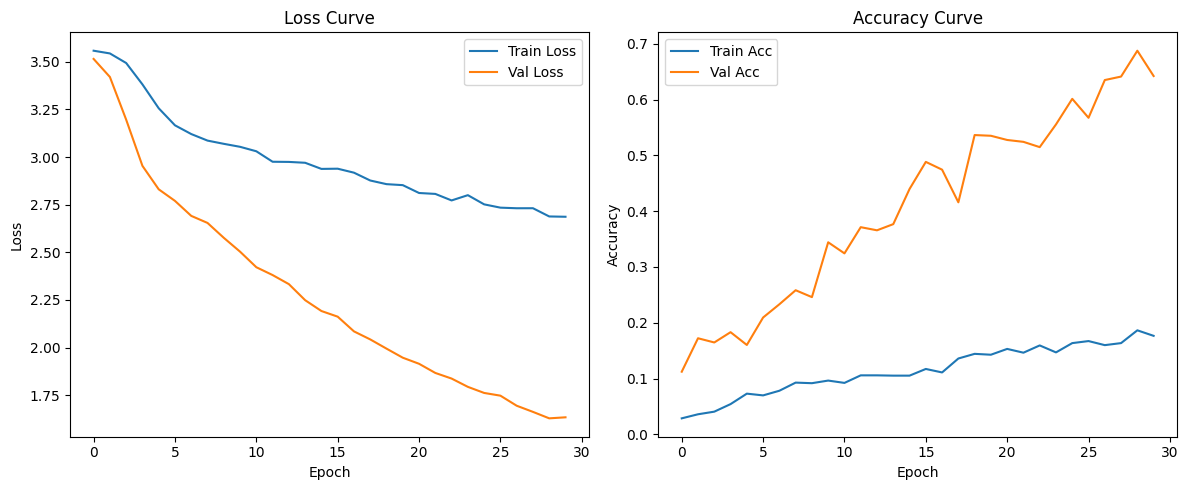

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 1.6157617001849203
Test Accuracy: 0.694198939418287


In [14]:
print(classification_report(
    y_true,
    y_pred,
    target_names=[idx_to_class[i] for i in range(num_classes)]
))

              precision    recall  f1-score   support

           1       0.92      0.97      0.94       179
           2       0.89      0.42      0.58       179
           3       0.99      1.00      1.00       179
           4       0.54      1.00      0.70       179
           5       0.95      1.00      0.98       179
           6       0.62      0.22      0.33       179
           7       0.65      1.00      0.79       179
           8       1.00      1.00      1.00       179
           9       0.82      1.00      0.90       179
           A       1.00      0.53      0.69       179
           B       1.00      0.15      0.26       177
           C       0.88      0.91      0.90       193
           D       0.59      0.50      0.54       179
           E       0.97      0.96      0.96       179
           F       0.81      0.58      0.68       179
           G       0.11      0.01      0.01       179
           H       0.51      0.95      0.66       179
           I       0.68    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


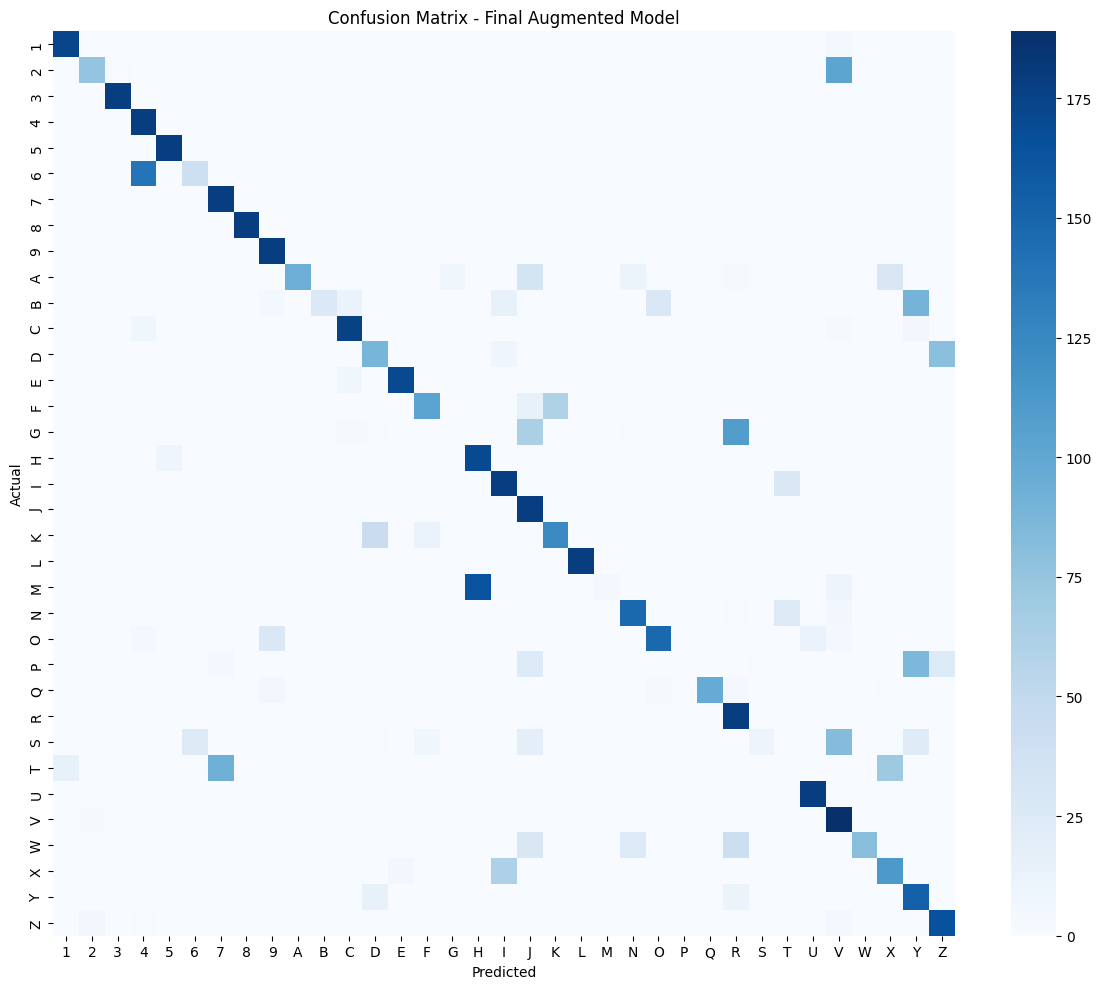

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=[idx_to_class[i] for i in range(num_classes)],
    yticklabels=[idx_to_class[i] for i in range(num_classes)]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Augmented Model")
plt.tight_layout()
plt.show()

In [16]:
results_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred,
    "true_class": [idx_to_class[i] for i in y_true],
    "pred_class": [idx_to_class[i] for i in y_pred]
})

results_file = model_dir / "final_predictions.csv"
results_df.to_csv(results_file, index=False)

print("Saved results to:", results_file)

Saved results to: /content/drive/MyDrive/ISL_GAN_FewShot_Project/models/fewshot/final_predictions.csv
